In [27]:
# Setup

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import os

# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

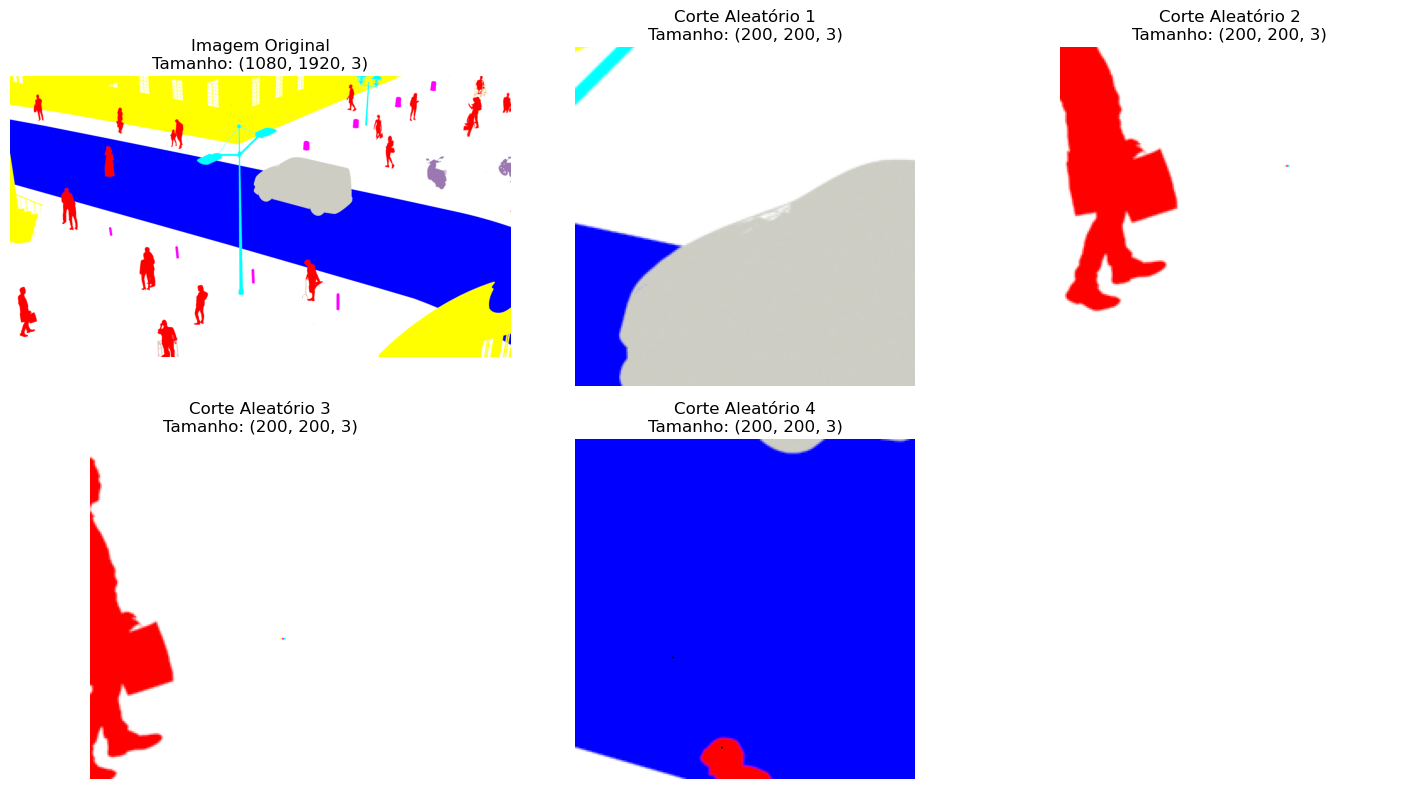

Dimensões da imagem original: (1080, 1920, 3)
Dimensões após o corte aleatório: (200, 200, 3)


In [28]:
# Testes das classes de Aumento de Dados do Keras 3

# https://keras.io/api/layers/preprocessing_layers/image_augmentation/random_crop/

import tensorflow as tf
import matplotlib.pyplot as plt

# Carregar uma imagem
# image_path = 'caminho/para/sua/imagem.jpg'
image = tf.keras.utils.load_img(mask_path)
image_tensor = tf.keras.utils.img_to_array(image)

# Expandir dimensões para simular um batch
image_batch = tf.expand_dims(image_tensor, 0)

# Criar a camada RandomCrop
random_crop_layer = tf.keras.layers.RandomCrop(height=200, width=200, seed=42)

# Gerar múltiplos cortes aleatórios
num_crops = 4
crops = []
for i in range(num_crops):
    # Definir 'training=True' para forçar cortes aleatórios
    cropped = random_crop_layer(image_batch, training=True)
    crops.append(cropped[0])  # Removendo a dimensão do batch

# Visualizar a imagem original e os cortes
plt.figure(figsize=(15, 8))

# Imagem original
plt.subplot(2, 3, 1)
plt.imshow(image_tensor.astype('uint8'))
plt.title(f'Imagem Original\nTamanho: {image_tensor.shape}')
plt.axis('off')

# Cortes aleatórios
for i, crop in enumerate(crops):
    plt.subplot(2, 3, i + 2)
    plt.imshow(crop.numpy().astype('uint8'))
    plt.title(f'Corte Aleatório {i+1}\nTamanho: {crop.shape}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Mostrar as dimensões
print("Dimensões da imagem original:", image_tensor.shape)
print("Dimensões após o corte aleatório:", crops[0].shape)

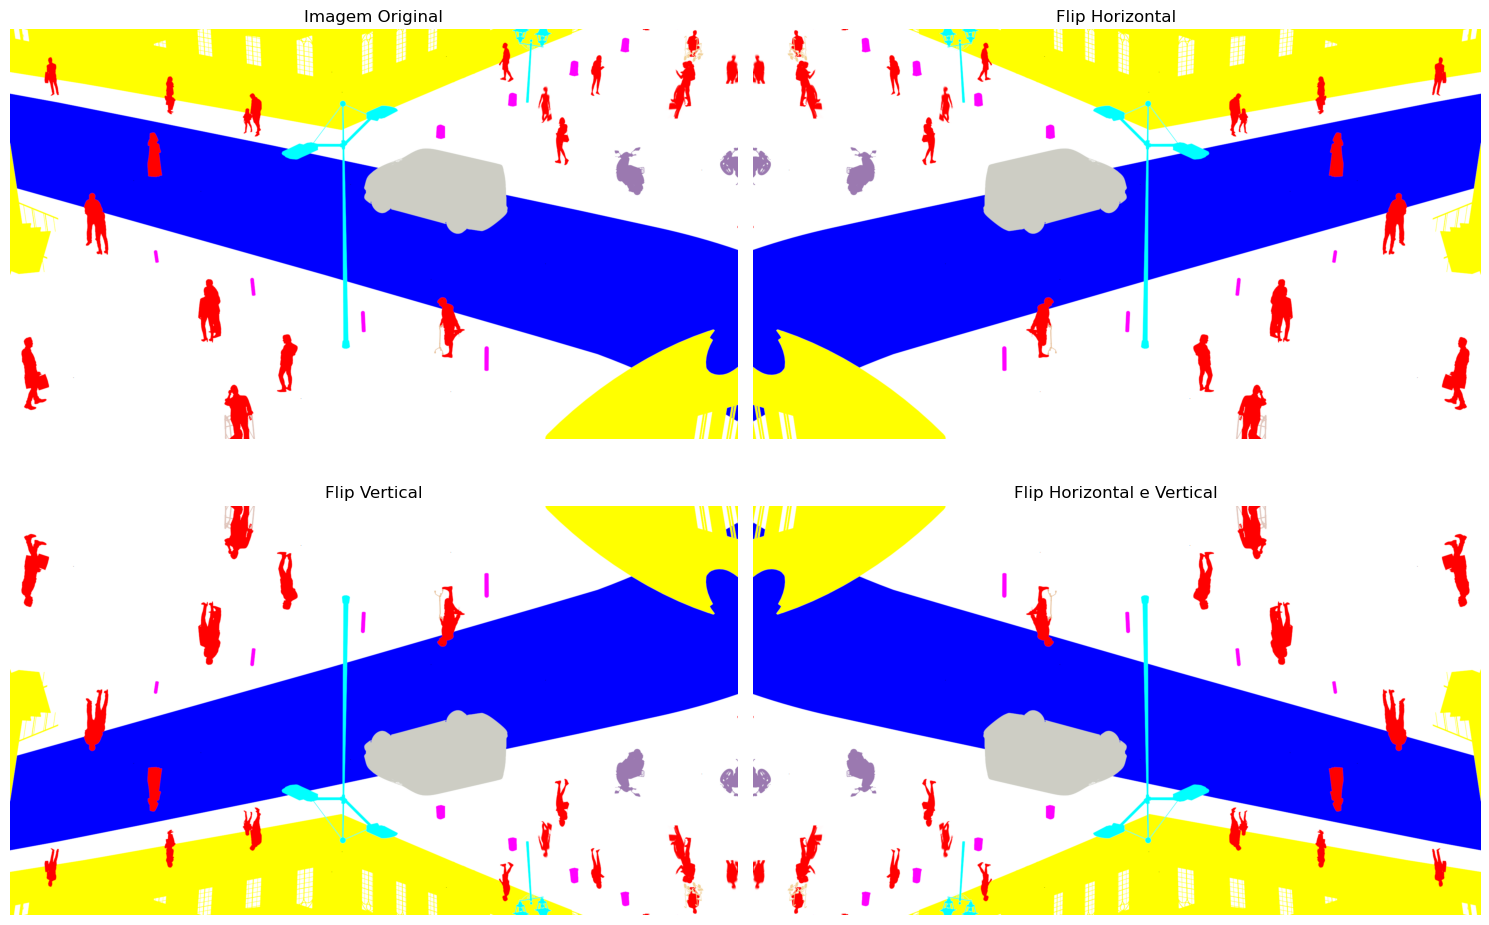

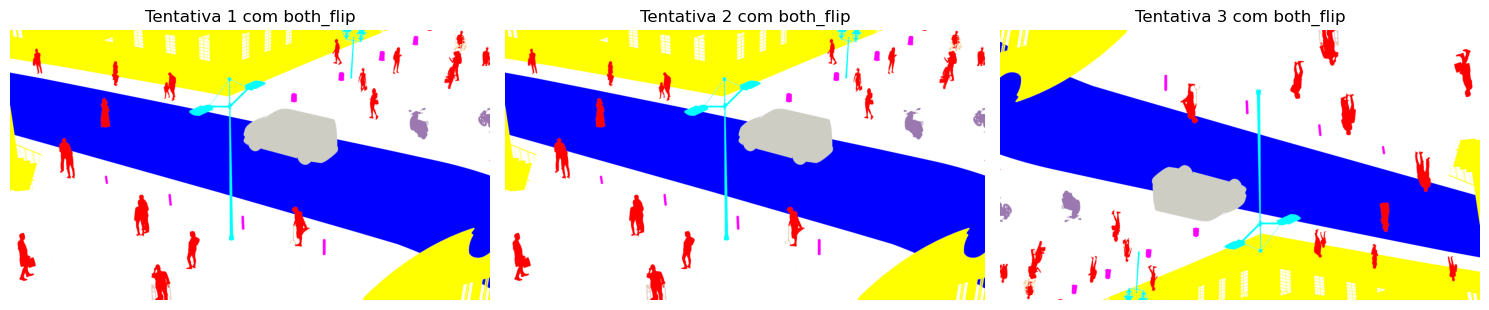

In [29]:
# https://keras.io/api/layers/preprocessing_layers/image_augmentation/random_flip/
# keras.layers.RandomFlip(mode="horizontal_and_vertical", seed=None, data_format=None, **kwargs)

import tensorflow as tf
import matplotlib.pyplot as plt

# Carregar uma imagem
# image_path = 'caminho/para/sua/imagem.jpg'
image = tf.keras.utils.load_img(mask_path)
image_tensor = tf.keras.utils.img_to_array(image)

# Expandir dimensões para simular um batch
image_batch = tf.expand_dims(image_tensor, 0)

# Criar as camadas RandomFlip com diferentes modos
horizontal_flip = tf.keras.layers.RandomFlip("horizontal", seed=42)
vertical_flip = tf.keras.layers.RandomFlip("vertical", seed=42)
both_flip = tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=42) # Padrão

# Aplicar os diferentes tipos de flip, 'training=True' para forçar o flip
flipped_h = horizontal_flip(image_batch, training=True)
flipped_v = vertical_flip(image_batch, training=True)
flipped_hv = both_flip(image_batch, training=True)

# Visualizar os resultados
plt.figure(figsize=(15, 10))

# Imagem original
plt.subplot(2, 2, 1)
plt.imshow(image_tensor.astype('uint8'))
plt.title('Imagem Original')
plt.axis('off')

# Flip horizontal
plt.subplot(2, 2, 2)
plt.imshow(flipped_h[0].numpy().astype('uint8'))
plt.title('Flip Horizontal')
plt.axis('off')

# Flip vertical
plt.subplot(2, 2, 3)
plt.imshow(flipped_v[0].numpy().astype('uint8'))
plt.title('Flip Vertical')
plt.axis('off')

# Flip horizontal e vertical
plt.subplot(2, 2, 4)
plt.imshow(flipped_hv[0].numpy().astype('uint8'))
plt.title('Flip Horizontal e Vertical')
plt.axis('off')

plt.tight_layout()
plt.show()

# Demonstrar comportamento aleatório
plt.figure(figsize=(15, 5))
for i in range(3):
    # A cada iteração, pode haver ou não o flip
    flipped = both_flip(image_batch, training=True)
    plt.subplot(1, 3, i + 1)
    plt.imshow(flipped[0].numpy().astype('uint8'))
    plt.title(f'Tentativa {i+1} com both_flip')
    plt.axis('off')

plt.tight_layout()
plt.show()

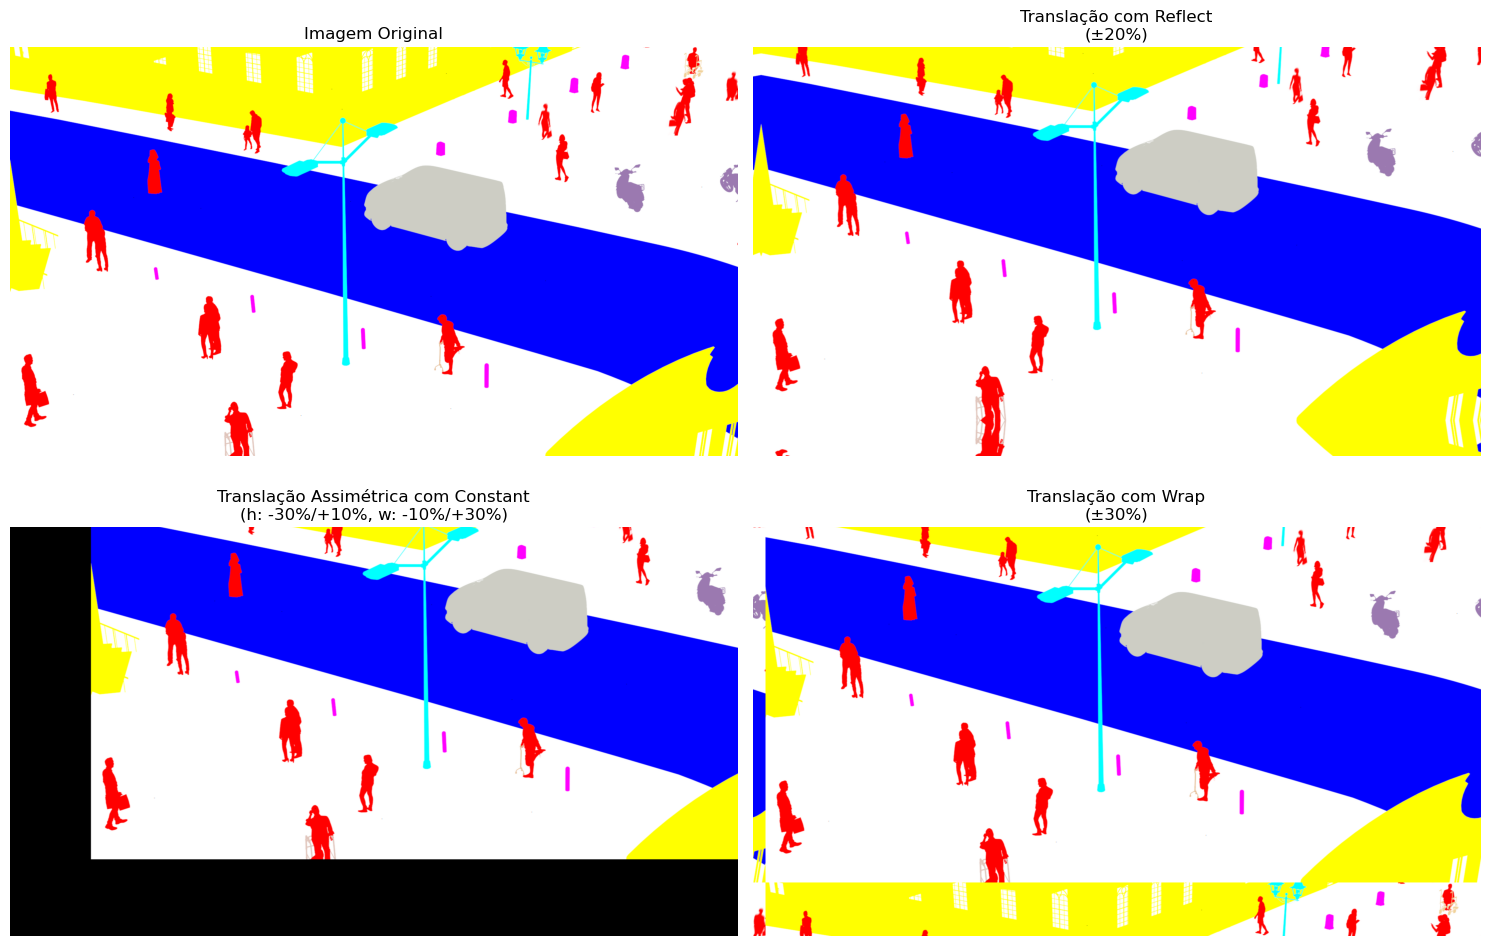

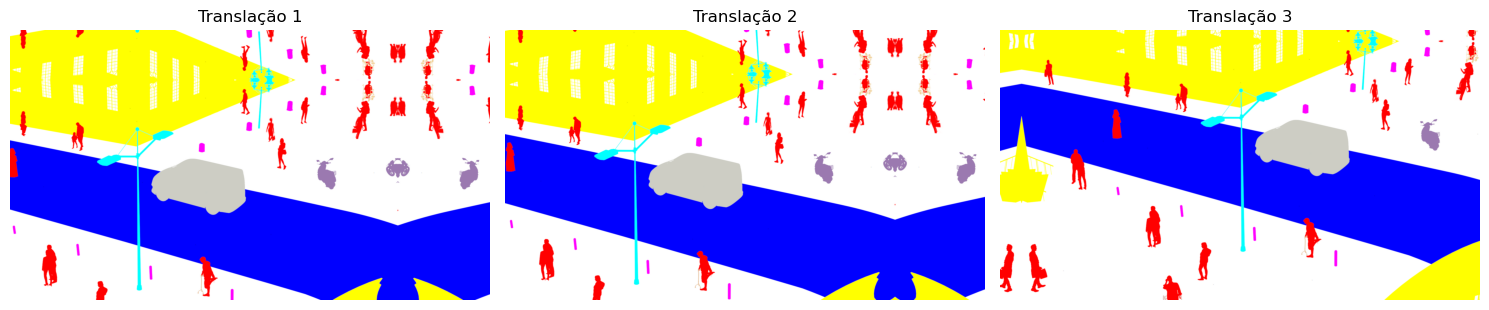

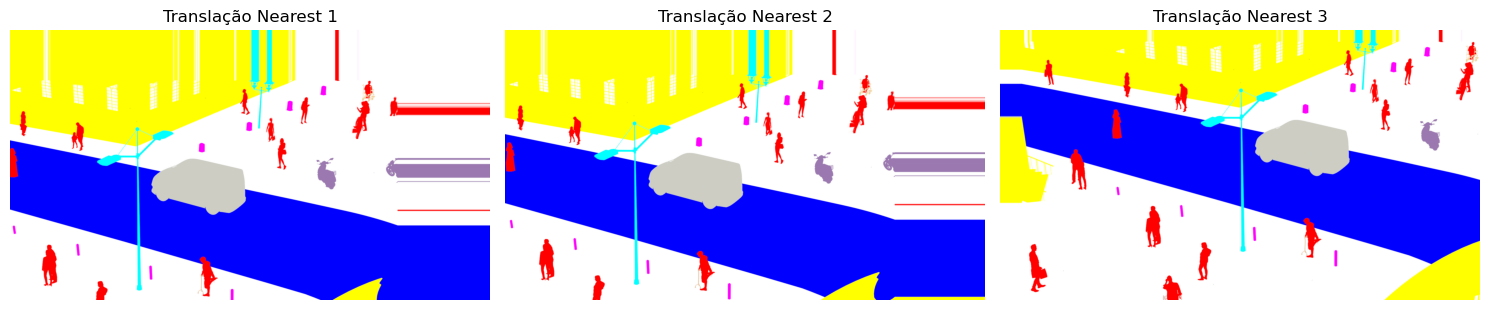

In [30]:
# https://keras.io/api/layers/preprocessing_layers/image_augmentation/random_translation/

"""
Diferentes modos de preenchimento (fill_mode):
"reflect": reflete a imagem nas bordas
"constant": preenche com valor constante
"wrap": enrola a imagem nas bordas
"""

import tensorflow as tf
import matplotlib.pyplot as plt

# Carregar uma imagem
# image_path = 'caminho/para/sua/imagem.jpg'
image = tf.keras.utils.load_img(mask_path)
image_tensor = tf.keras.utils.img_to_array(image)
image_batch = tf.expand_dims(image_tensor, 0)

# Criar diferentes camadas de RandomTranslation
# 1. Translação simétrica com reflect
translation_symmetric = tf.keras.layers.RandomTranslation(
    height_factor=0.2,  # [-20%, +20%]
    width_factor=0.2,   # [-20%, +20%]
    fill_mode="reflect",
    interpolation="bilinear",
    seed=42
)

# 2. Translação assimétrica com constant fill
translation_asymmetric = tf.keras.layers.RandomTranslation(
    height_factor=(-0.3, 0.1),  # [-30%, +10%]
    width_factor=(-0.1, 0.3),   # [-10%, +30%]
    fill_mode="constant",
    fill_value=0.0,
    seed=42
)

# 3. Translação com wrap
translation_wrap = tf.keras.layers.RandomTranslation(
    height_factor=0.3,  # [-30%, +30%]
    width_factor=0.3,   # [-30%, +30%]
    fill_mode="wrap",
    seed=42
)

# 4. Translação com nearest
translation_nearest = tf.keras.layers.RandomTranslation(
    height_factor=0.2,  # [-20%, +20%]
    width_factor=0.2,   # [-20%, +20%]
    fill_mode="nearest",
    interpolation="bilinear",
    seed=42
)

# Aplicar as transformações
translated_reflect = translation_symmetric(image_batch, training=True)
translated_constant = translation_asymmetric(image_batch, training=True)
translated_wrap = translation_wrap(image_batch, training=True)
translated_nearest = translation_nearest(image_batch, training=True)

# Visualizar os resultados
plt.figure(figsize=(15, 10))

# Imagem original
plt.subplot(2, 2, 1)
plt.imshow(image_tensor.astype('uint8'))
plt.title('Imagem Original')
plt.axis('off')

# Translação com reflect
plt.subplot(2, 2, 2)
plt.imshow(translated_reflect[0].numpy().astype('uint8'))
plt.title('Translação com Reflect\n(±20%)')
plt.axis('off')

# Translação com constant
plt.subplot(2, 2, 3)
plt.imshow(translated_constant[0].numpy().astype('uint8'))
plt.title('Translação Assimétrica com Constant\n(h: -30%/+10%, w: -10%/+30%)')
plt.axis('off')

# Translação com wrap
plt.subplot(2, 2, 4)
plt.imshow(translated_wrap[0].numpy().astype('uint8'))
plt.title('Translação com Wrap\n(±30%)')
plt.axis('off')

plt.tight_layout()
plt.show()

# Demonstrar múltiplas aplicações da mesma transformação
plt.figure(figsize=(15, 5))
for i in range(3):
    translated = translation_symmetric(image_batch, training=True)
    plt.subplot(1, 3, i + 1)
    plt.imshow(translated[0].numpy().astype('uint8'))
    plt.title(f'Translação {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Demonstrar múltiplas aplicações da translação com nearest
plt.figure(figsize=(15, 5))
for i in range(3):
    translated = translation_nearest(image_batch, training=True)
    plt.subplot(1, 3, i + 1)
    plt.imshow(translated[0].numpy().astype('uint8'))
    plt.title(f'Translação Nearest {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

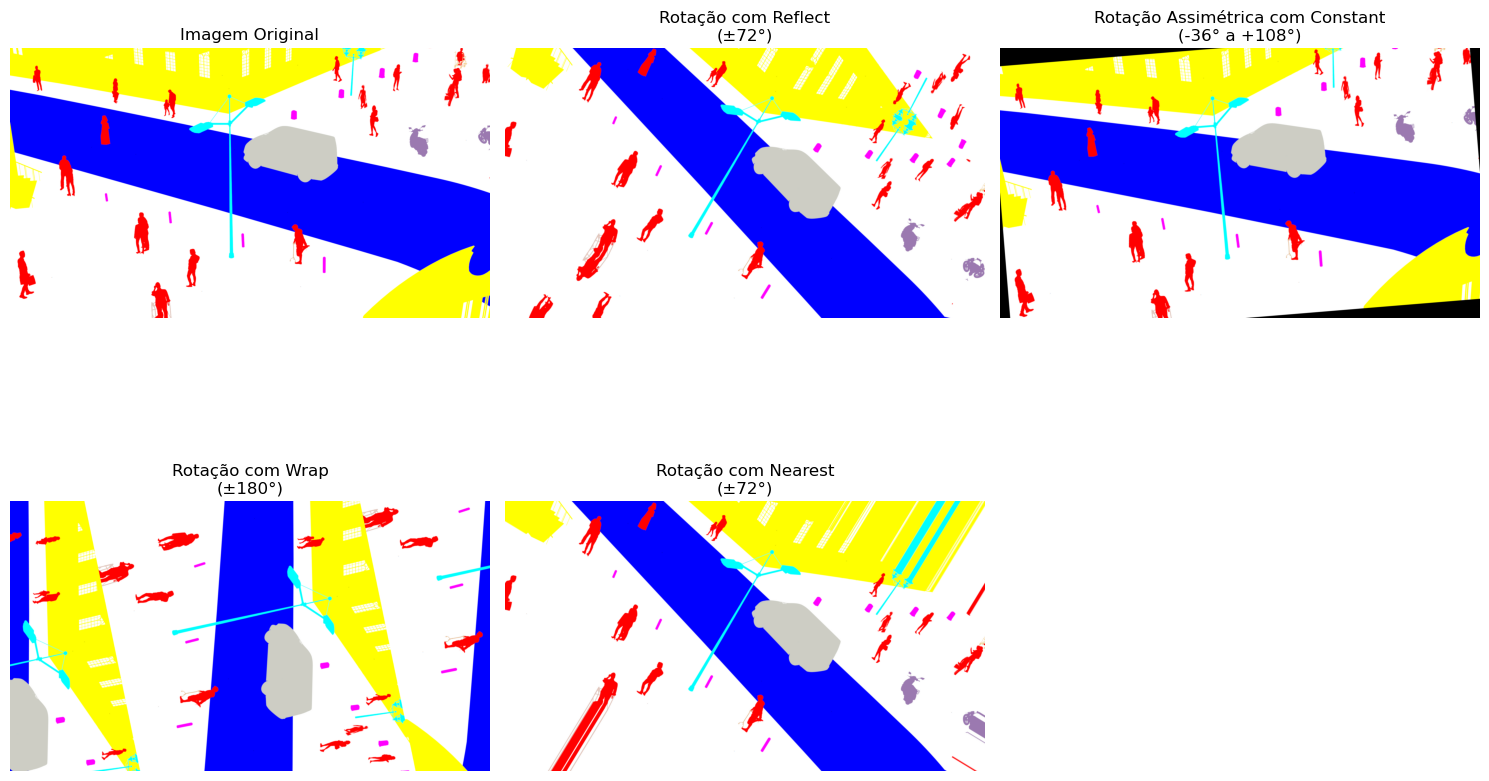

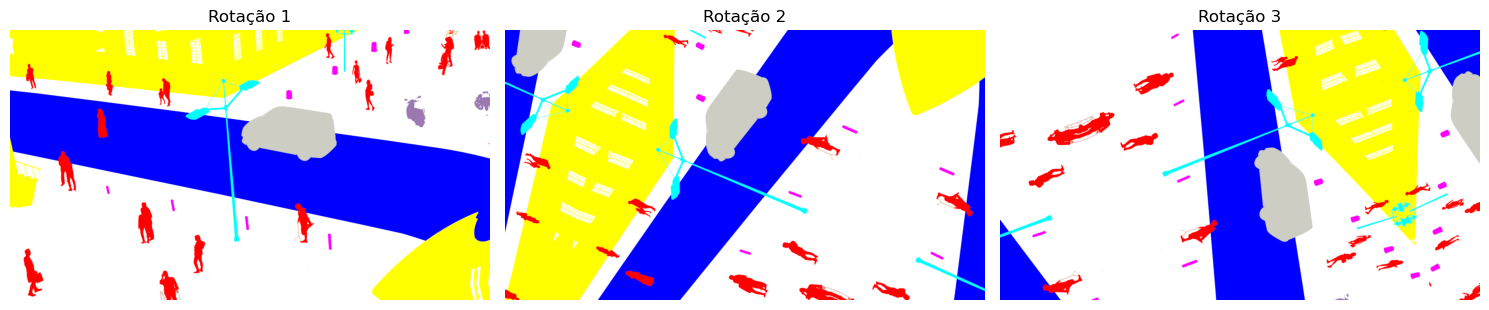

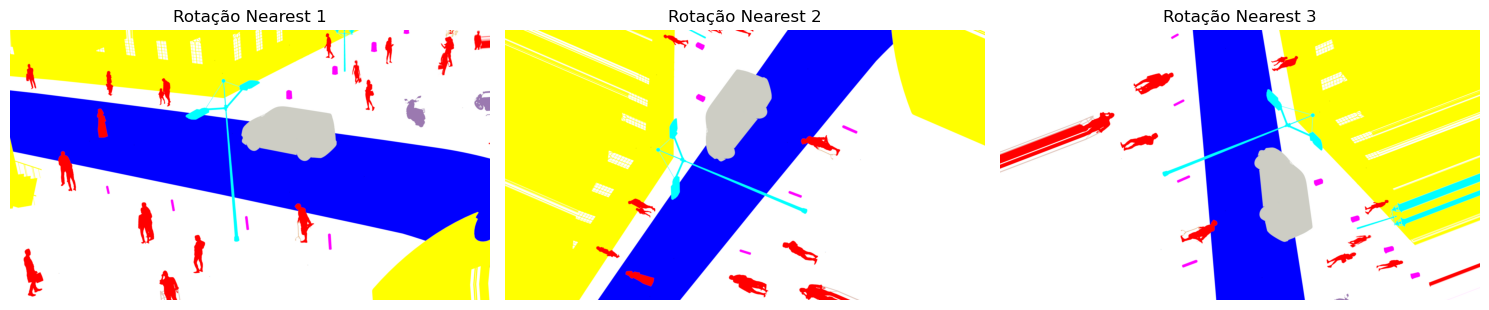

In [31]:
# https://keras.io/api/layers/preprocessing_layers/image_augmentation/random_rotation/

import tensorflow as tf
import matplotlib.pyplot as plt

# Carregar uma imagem
# image_path = 'caminho/para/sua/imagem.jpg'
image = tf.keras.utils.load_img(mask_path)
image_tensor = tf.keras.utils.img_to_array(image)
image_batch = tf.expand_dims(image_tensor, 0)

# Criar diferentes camadas de RandomRotation
# 1. Rotação simétrica com reflect
rotation_symmetric = tf.keras.layers.RandomRotation(
    factor=0.2,  # [-20% * 360°, +20% * 360°] = [-72°, +72°]
    fill_mode="reflect",
    interpolation="bilinear",
    seed=42
)

# 2. Rotação assimétrica com constant fill
rotation_asymmetric = tf.keras.layers.RandomRotation(
    factor=(-0.1, 0.3),  # [-10% * 360°, +30% * 360°] = [-36°, +108°]
    fill_mode="constant",
    fill_value=0.0,
    seed=42
)

# 3. Rotação com wrap
rotation_wrap = tf.keras.layers.RandomRotation(
    factor=0.5,  # [-50% * 360°, +50% * 360°] = [-180°, +180°]
    fill_mode="wrap",
    seed=42
)

# 4. Rotação com nearest
rotation_nearest = tf.keras.layers.RandomRotation(
    factor=0.2,  # [-72°, +72°]
    fill_mode="nearest",
    interpolation="bilinear",
    seed=42
)

# Aplicar as rotações
rotated_reflect = rotation_symmetric(image_batch, training=True)
rotated_constant = rotation_asymmetric(image_batch, training=True)
rotated_wrap = rotation_wrap(image_batch, training=True)
rotated_nearest = rotation_nearest(image_batch, training=True)

# Visualizar os resultados
plt.figure(figsize=(15, 10))

# Imagem original
plt.subplot(2, 3, 1)
plt.imshow(image_tensor.astype('uint8'))
plt.title('Imagem Original')
plt.axis('off')

# Rotação com reflect
plt.subplot(2, 3, 2)
plt.imshow(rotated_reflect[0].numpy().astype('uint8'))
plt.title('Rotação com Reflect\n(±72°)')
plt.axis('off')

# Rotação com constant
plt.subplot(2, 3, 3)
plt.imshow(rotated_constant[0].numpy().astype('uint8'))
plt.title('Rotação Assimétrica com Constant\n(-36° a +108°)')
plt.axis('off')

# Rotação com wrap
plt.subplot(2, 3, 4)
plt.imshow(rotated_wrap[0].numpy().astype('uint8'))
plt.title('Rotação com Wrap\n(±180°)')
plt.axis('off')

# Rotação com nearest
plt.subplot(2, 3, 5)
plt.imshow(rotated_nearest[0].numpy().astype('uint8'))
plt.title('Rotação com Nearest\n(±72°)')
plt.axis('off')

plt.tight_layout()
plt.show()

# Demonstrar múltiplas aplicações da mesma transformação
plt.figure(figsize=(15, 5))
for i in range(3):
    rotated = rotation_symmetric(image_batch, training=True)
    plt.subplot(1, 3, i + 1)
    plt.imshow(rotated[0].numpy().astype('uint8'))
    plt.title(f'Rotação {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Demonstrar o efeito do nearest em múltiplas aplicações
plt.figure(figsize=(15, 5))
for i in range(3):
    rotated = rotation_nearest(image_batch, training=True)
    plt.subplot(1, 3, i + 1)
    plt.imshow(rotated[0].numpy().astype('uint8'))
    plt.title(f'Rotação Nearest {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

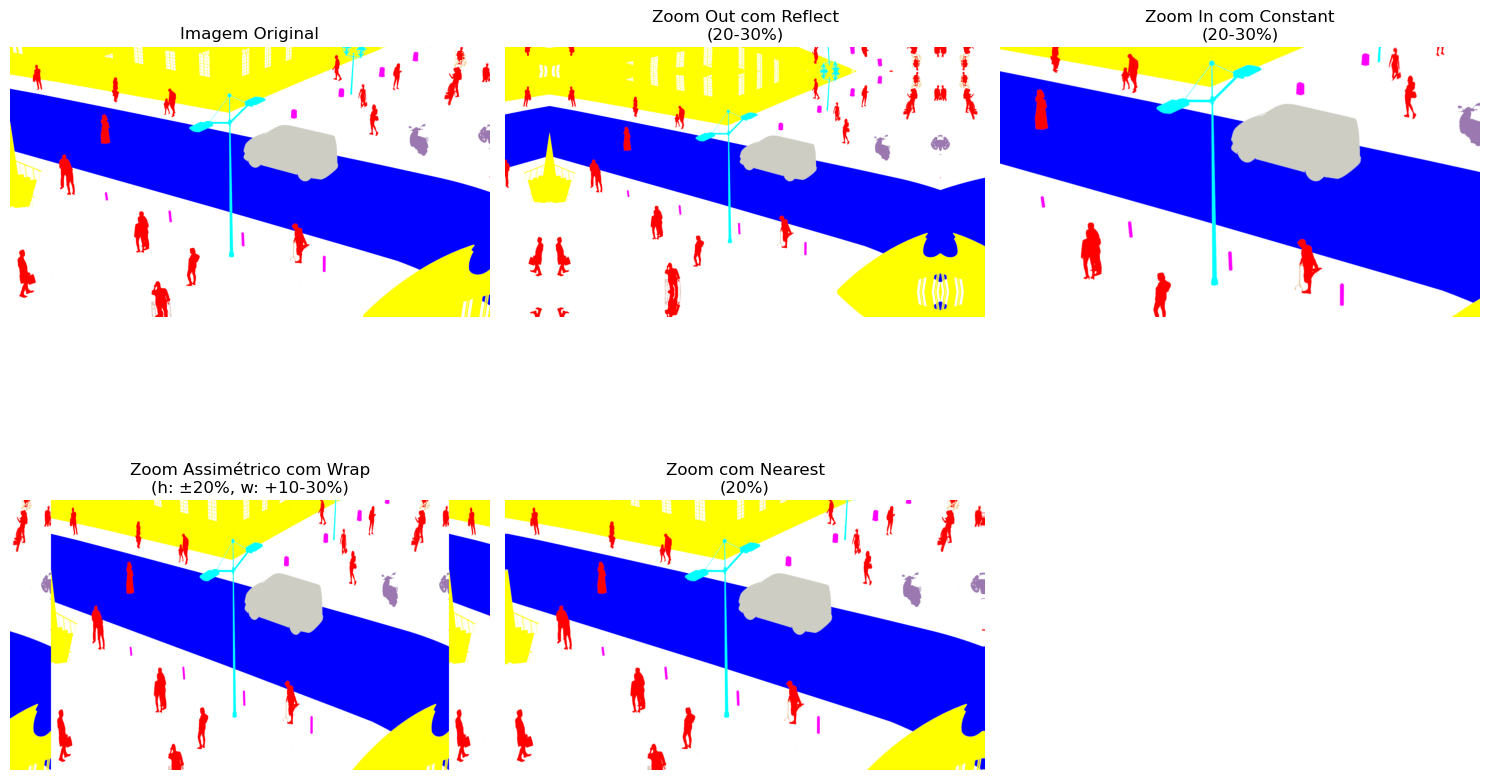

In [32]:
# https://keras.io/api/layers/preprocessing_layers/image_augmentation/random_zoom/

import tensorflow as tf
import matplotlib.pyplot as plt

# Carregar uma imagem
# image_path = 'caminho/para/sua/imagem.jpg'
image = tf.keras.utils.load_img(mask_path)
image_tensor = tf.keras.utils.img_to_array(image)
image_batch = tf.expand_dims(image_tensor, 0)

# Criar diferentes camadas de RandomZoom
# 1. Zoom simétrico com reflect (zoom out)
zoom_out = tf.keras.layers.RandomZoom(
    height_factor=(0.2, 0.3),  # Zoom out 20-30%
    width_factor=None,  # Mantém aspect ratio
    fill_mode="reflect",
    interpolation="bilinear",
    seed=42
)

# 2. Zoom simétrico com constant (zoom in)
zoom_in = tf.keras.layers.RandomZoom(
    height_factor=(-0.3, -0.2),  # Zoom in 20-30%
    width_factor=None,  # Mantém aspect ratio
    fill_mode="constant",
    fill_value=0.0,
    seed=42
)

# 3. Zoom assimétrico com wrap
zoom_asymmetric = tf.keras.layers.RandomZoom(
    height_factor=(-0.2, 0.2),  # Zoom in/out 20%
    width_factor=(0.1, 0.3),    # Zoom out 10-30%
    fill_mode="wrap",
    seed=42
)

# 4. Zoom com nearest
zoom_nearest = tf.keras.layers.RandomZoom(
    height_factor=0.2,  # Zoom out 20%
    width_factor=0.2,   # Zoom out 20%
    fill_mode="nearest",
    interpolation="bilinear",
    seed=42
)

# Aplicar os zooms
zoomed_out = zoom_out(image_batch, training=True)
zoomed_in = zoom_in(image_batch, training=True)
zoomed_asymmetric = zoom_asymmetric(image_batch, training=True)
zoomed_nearest = zoom_nearest(image_batch, training=True)

# Visualizar os resultados
plt.figure(figsize=(15, 10))

# Imagem original
plt.subplot(2, 3, 1)
plt.imshow(image_tensor.astype('uint8'))
plt.title('Imagem Original')
plt.axis('off')

# Zoom out com reflect
plt.subplot(2, 3, 2)
plt.imshow(zoomed_out[0].numpy().astype('uint8'))
plt.title('Zoom Out com Reflect\n(20-30%)')
plt.axis('off')

# Zoom in com constant
plt.subplot(2, 3, 3)
plt.imshow(zoomed_in[0].numpy().astype('uint8'))
plt.title('Zoom In com Constant\n(20-30%)')
plt.axis('off')

# Zoom assimétrico com wrap
plt.subplot(2, 3, 4)
plt.imshow(zoomed_asymmetric[0].numpy().astype('uint8'))
plt.title('Zoom Assimétrico com Wrap\n(h: ±20%, w: +10-30%)')
plt.axis('off')

# Zoom com nearest
plt.subplot(2, 3, 5)
plt.imshow(zoomed_nearest[0].numpy().astype('uint8'))
plt.title('Zoom com Nearest\n(20%)')
plt.axis('off')

plt.tight_layout()
plt.show()

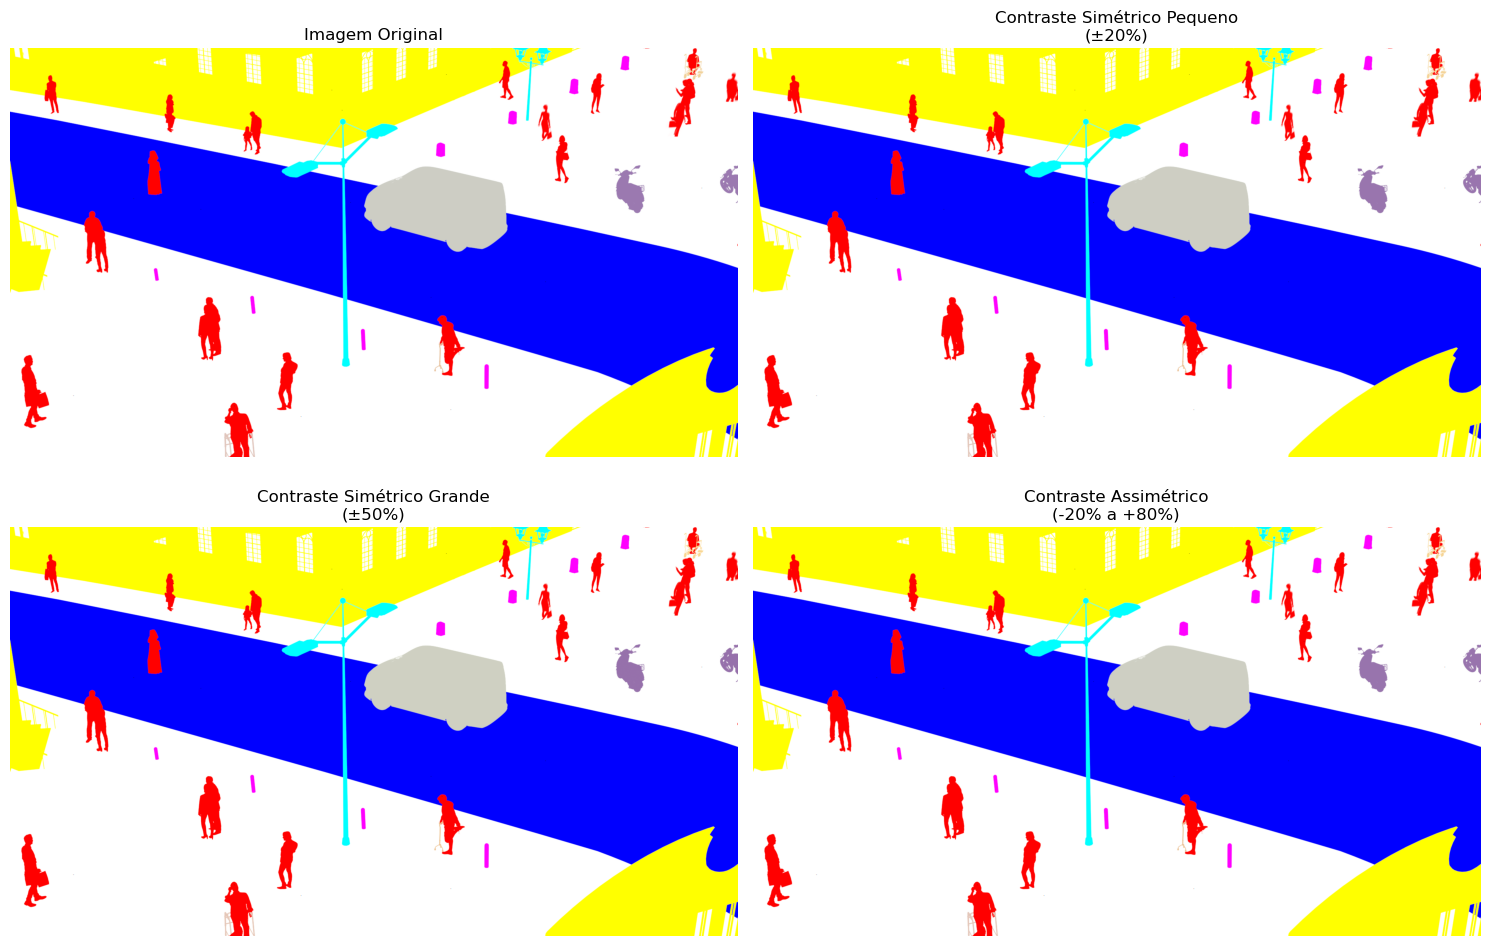

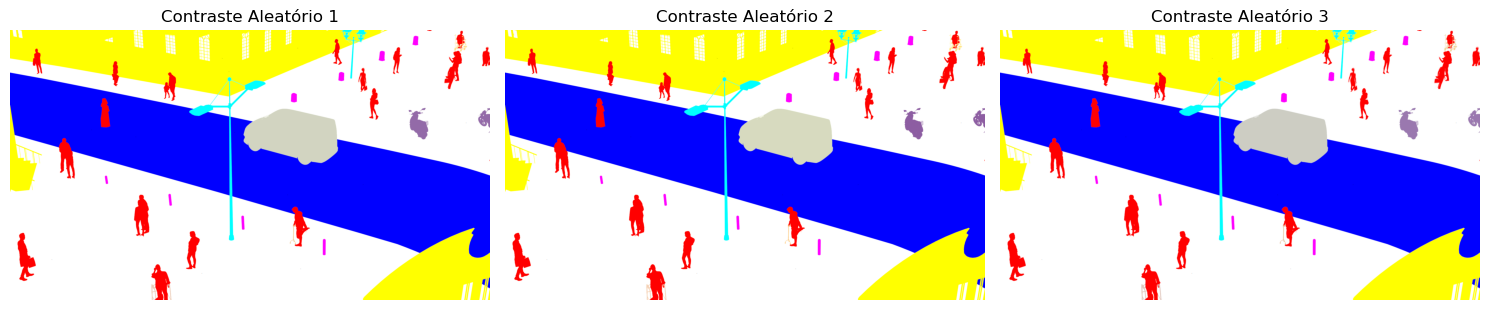

Valores na imagem original: Min: 0.00, Max: 255.00
Valores após contraste pequeno: Min: 0.00, Max: 255.00
Valores após contraste grande: Min: 0.00, Max: 255.00
Valores após contraste assimétrico: Min: 0.00, Max: 255.00


In [38]:
# https://keras.io/api/layers/preprocessing_layers/image_augmentation/random_contrast/
"""
https://www.tensorflow.org/api_docs/python/tf/keras/layers/RandomContrast
tf.keras.layers.RandomContrast(factor, seed=None, **kwargs)
"""

import tensorflow as tf
import matplotlib.pyplot as plt


# Carregar uma imagem
# image_path = 'caminho/para/sua/imagem.jpg'
image = tf.keras.utils.load_img(mask_path)
image_tensor = tf.keras.utils.img_to_array(image)
image_batch = tf.expand_dims(image_tensor, 0)

# Criar diferentes camadas de RandomContrast
# 1. Contraste simétrico com range pequeno
contrast_small = tf.keras.layers.RandomContrast(
    factor=0.2,  # Fator de contraste entre [0.8, 1.2]
    # value_range=(0, 255),
    seed=42
)

# 2. Contraste simétrico com range maior
contrast_large = tf.keras.layers.RandomContrast(
    factor=0.5,  # Fator de contraste entre [0.5, 1.5]
    # value_range=(0, 255),
    seed=42
)

# 3. Contraste assimétrico
contrast_asymmetric = tf.keras.layers.RandomContrast(
    factor=(0.2, 0.8),  # Fator de contraste entre [0.8, 1.8]
    # value_range=(0, 255),
    seed=42
)

# Aplicar os ajustes de contraste
contrasted_small = contrast_small(image_batch, training=True)
contrasted_large = contrast_large(image_batch, training=True)
contrasted_asymmetric = contrast_asymmetric(image_batch, training=True)

# Visualizar os resultados
plt.figure(figsize=(15, 10))

# Imagem original
plt.subplot(2, 2, 1)
plt.imshow(image_tensor.astype('uint8'))
plt.title('Imagem Original')
plt.axis('off')

# Contraste pequeno
plt.subplot(2, 2, 2)
plt.imshow(contrasted_small[0].numpy().astype('uint8'))
plt.title('Contraste Simétrico Pequeno\n(±20%)')
plt.axis('off')

# Contraste grande
plt.subplot(2, 2, 3)
plt.imshow(contrasted_large[0].numpy().astype('uint8'))
plt.title('Contraste Simétrico Grande\n(±50%)')
plt.axis('off')

# Contraste assimétrico
plt.subplot(2, 2, 4)
plt.imshow(contrasted_asymmetric[0].numpy().astype('uint8'))
plt.title('Contraste Assimétrico\n(-20% a +80%)')
plt.axis('off')

plt.tight_layout()
plt.show()

# Demonstrar múltiplas aplicações do mesmo ajuste de contraste
plt.figure(figsize=(15, 5))
for i in range(3):
    contrasted = contrast_large(image_batch, training=True)
    plt.subplot(1, 3, i + 1)
    plt.imshow(contrasted[0].numpy().astype('uint8'))
    plt.title(f'Contraste Aleatório {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Mostrar os valores mínimos e máximos
print("Valores na imagem original:", 
        f"Min: {tf.reduce_min(image_tensor):.2f}, Max: {tf.reduce_max(image_tensor):.2f}")
print("Valores após contraste pequeno:", 
        f"Min: {tf.reduce_min(contrasted_small):.2f}, Max: {tf.reduce_max(contrasted_small):.2f}")
print("Valores após contraste grande:", 
        f"Min: {tf.reduce_min(contrasted_large):.2f}, Max: {tf.reduce_max(contrasted_large):.2f}")
print("Valores após contraste assimétrico:", 
        f"Min: {tf.reduce_min(contrasted_asymmetric):.2f}, Max: {tf.reduce_max(contrasted_asymmetric):.2f}")

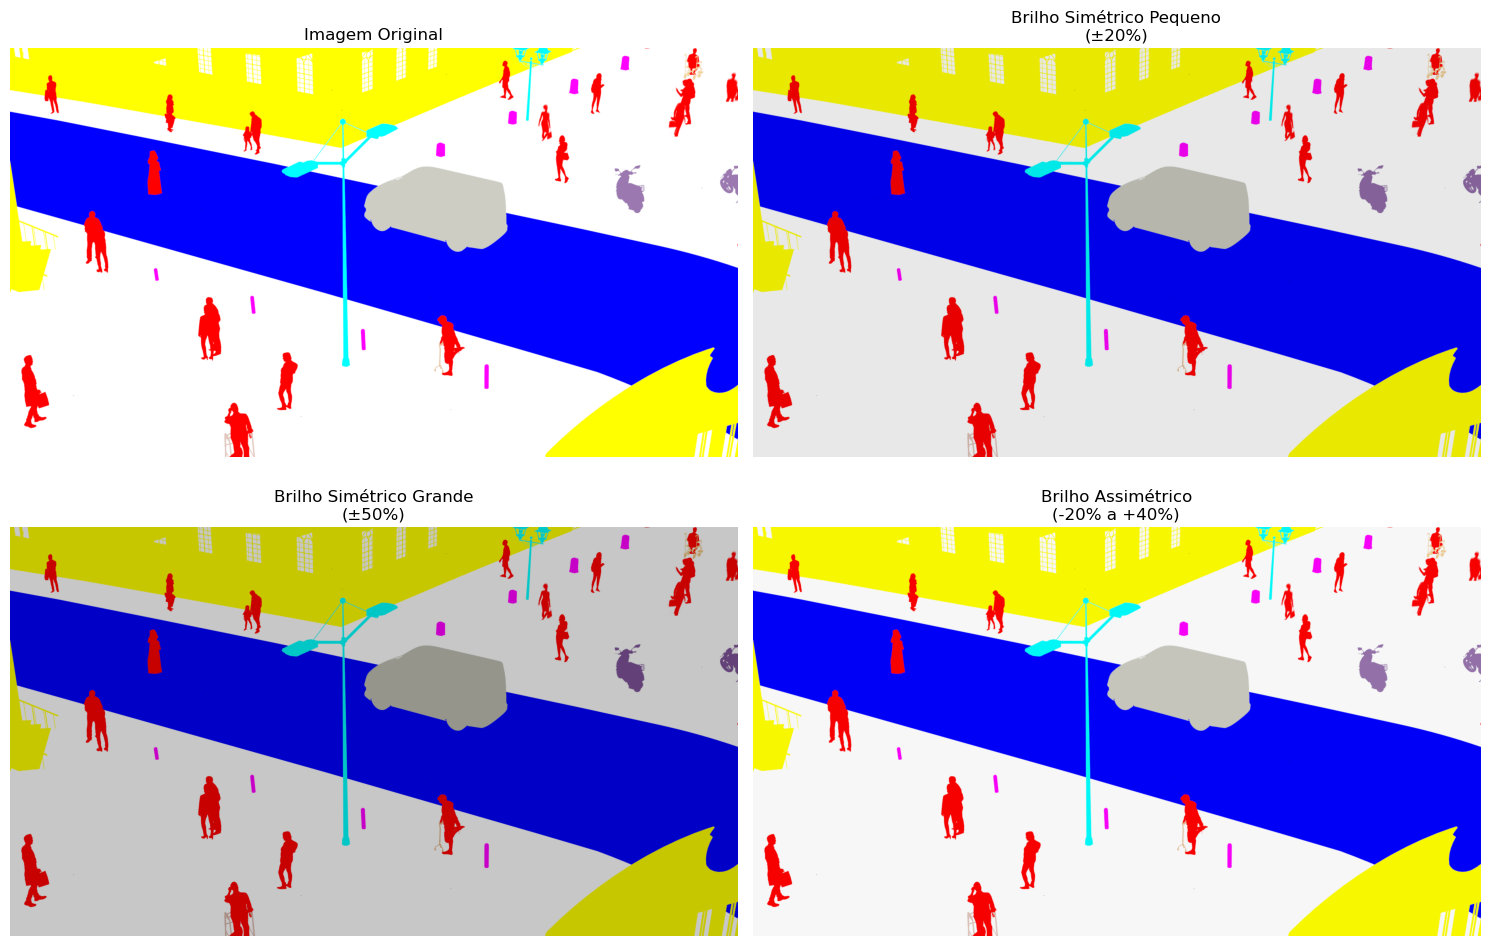

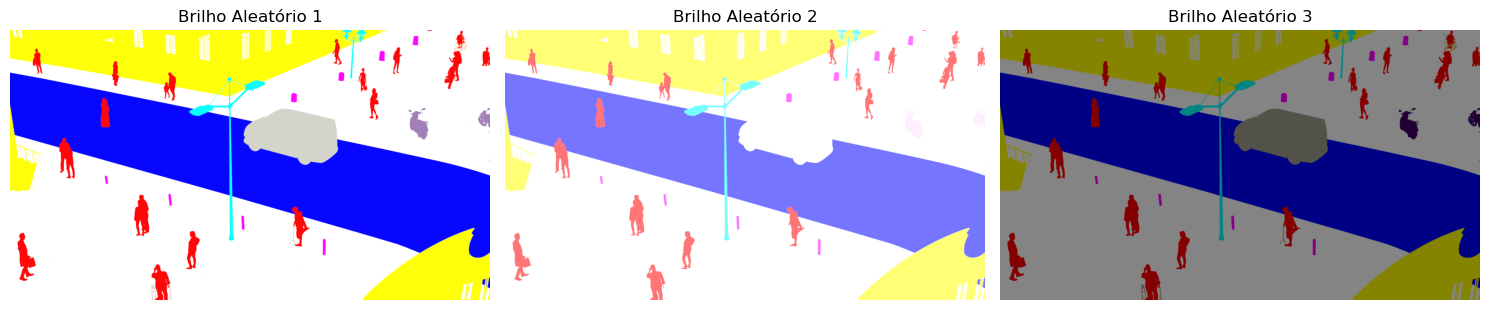

Valores na imagem original: Min: 0.00, Max: 255.00
Valores após brilho pequeno: Min: 0.00, Max: 232.81
Valores após brilho grande: Min: 0.00, Max: 199.52
Valores após brilho assimétrico: Min: 0.00, Max: 247.21


In [39]:
# https://keras.io/api/layers/preprocessing_layers/image_augmentation/random_brightness/

import tensorflow as tf
import matplotlib.pyplot as plt

# Carregar uma imagem
image = tf.keras.utils.load_img(mask_path)
image_tensor = tf.keras.utils.img_to_array(image)
image_batch = tf.expand_dims(image_tensor, 0)

# Criar diferentes camadas de RandomBrightness
# 1. Brilho simétrico com range pequeno
brightness_small = tf.keras.layers.RandomBrightness(
    factor=0.2,  # Fator entre -0.2 e 0.2
    seed=42
)

# 2. Brilho simétrico com range maior
brightness_large = tf.keras.layers.RandomBrightness(
    factor=0.5,  # Fator entre -0.5 e 0.5
    seed=42
)

# 3. Brilho assimétrico
brightness_asymmetric = tf.keras.layers.RandomBrightness(
    factor=(-0.2, 0.4),  # Fator entre -0.2 e 0.4
    seed=42
)

# Aplicar os ajustes de brilho
brightened_small = brightness_small(image_batch, training=True)
brightened_large = brightness_large(image_batch, training=True)
brightened_asymmetric = brightness_asymmetric(image_batch, training=True)

# Visualizar os resultados
plt.figure(figsize=(15, 10))

# Imagem original
plt.subplot(2, 2, 1)
plt.imshow(image_tensor.astype('uint8'))
plt.title('Imagem Original')
plt.axis('off')

# Brilho pequeno
plt.subplot(2, 2, 2)
plt.imshow(brightened_small[0].numpy().astype('uint8'))
plt.title('Brilho Simétrico Pequeno\n(±20%)')
plt.axis('off')

# Brilho grande
plt.subplot(2, 2, 3)
plt.imshow(brightened_large[0].numpy().astype('uint8'))
plt.title('Brilho Simétrico Grande\n(±50%)')
plt.axis('off')

# Brilho assimétrico
plt.subplot(2, 2, 4)
plt.imshow(brightened_asymmetric[0].numpy().astype('uint8'))
plt.title('Brilho Assimétrico\n(-20% a +40%)')
plt.axis('off')

plt.tight_layout()
plt.show()

# Demonstrar múltiplas aplicações do mesmo ajuste de brilho
plt.figure(figsize=(15, 5))
for i in range(3):
    brightened = brightness_large(image_batch, training=True)
    plt.subplot(1, 3, i + 1)
    plt.imshow(brightened[0].numpy().astype('uint8'))
    plt.title(f'Brilho Aleatório {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Mostrar os valores mínimos e máximos
print("Valores na imagem original:", 
        f"Min: {tf.reduce_min(image_tensor):.2f}, Max: {tf.reduce_max(image_tensor):.2f}")
print("Valores após brilho pequeno:", 
        f"Min: {tf.reduce_min(brightened_small):.2f}, Max: {tf.reduce_max(brightened_small):.2f}")
print("Valores após brilho grande:", 
        f"Min: {tf.reduce_min(brightened_large):.2f}, Max: {tf.reduce_max(brightened_large):.2f}")
print("Valores após brilho assimétrico:", 
        f"Min: {tf.reduce_min(brightened_asymmetric):.2f}, Max: {tf.reduce_max(brightened_asymmetric):.2f}")

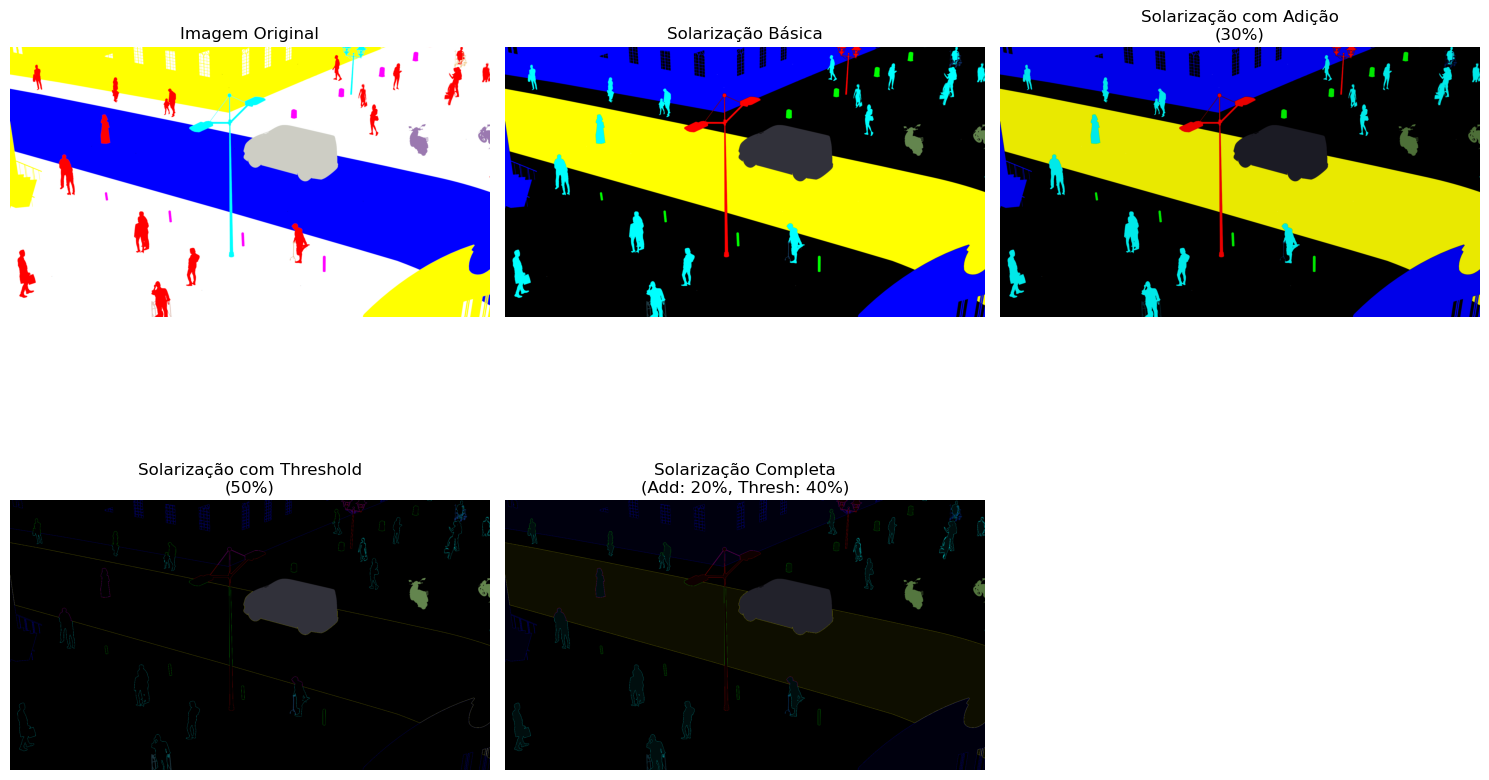

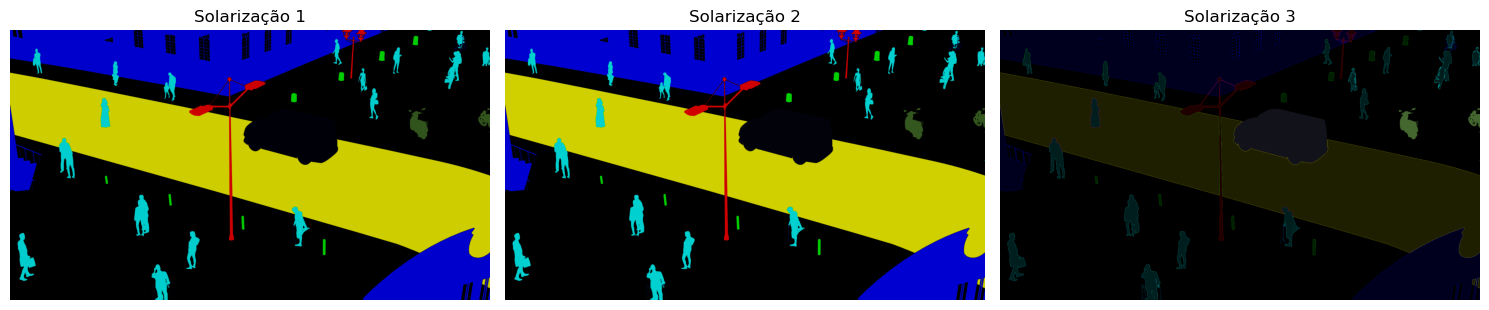

Valores na imagem original: Min: 0.00, Max: 255.00
Valores após solarização básica: Min: 0.00, Max: 255.00
Valores após solarização com adição: Min: 0.00, Max: 233.39
Valores após solarização com threshold: Min: 0.00, Max: 187.00
Valores após solarização completa: Min: 0.00, Max: 200.60


In [40]:
# https://keras.io/api/layers/preprocessing_layers/image_augmentation/solarization/

"""
A solarização é um efeito fotográfico onde ocorre uma inversão parcial ou total dos tons em uma imagem.
"""

import tensorflow as tf
import matplotlib.pyplot as plt


# Carregar uma imagem
image = tf.keras.utils.load_img(mask_path)
image_tensor = tf.keras.utils.img_to_array(image)
image_batch = tf.expand_dims(image_tensor, 0)

# Criar diferentes camadas de Solarization
# 1. Solarização básica
solarization_basic = tf.keras.layers.Solarization(
    value_range=(0, 255),
    seed=42
)

# 2. Solarização com adição
solarization_with_addition = tf.keras.layers.Solarization(
    addition_factor=0.3,  # Adiciona até 30% do valor_range antes da solarização
    value_range=(0, 255),
    seed=42
)

# 3. Solarização com threshold
solarization_with_threshold = tf.keras.layers.Solarization(
    threshold_factor=0.5,  # Solariza apenas pixels acima de 50% do value_range
    value_range=(0, 255),
    seed=42
)

# 4. Solarização completa
solarization_complete = tf.keras.layers.Solarization(
    addition_factor=0.2,
    threshold_factor=0.4,
    value_range=(0, 255),
    seed=42
)

# Aplicar as solarizações
solarized_basic = solarization_basic(image_batch, training=True)
solarized_addition = solarization_with_addition(image_batch, training=True)
solarized_threshold = solarization_with_threshold(image_batch, training=True)
solarized_complete = solarization_complete(image_batch, training=True)

# Visualizar os resultados
plt.figure(figsize=(15, 10))

# Imagem original
plt.subplot(2, 3, 1)
plt.imshow(image_tensor.astype('uint8'))
plt.title('Imagem Original')
plt.axis('off')

# Solarização básica
plt.subplot(2, 3, 2)
plt.imshow(solarized_basic[0].numpy().astype('uint8'))
plt.title('Solarização Básica')
plt.axis('off')

# Solarização com adição
plt.subplot(2, 3, 3)
plt.imshow(solarized_addition[0].numpy().astype('uint8'))
plt.title('Solarização com Adição\n(30%)')
plt.axis('off')

# Solarização com threshold
plt.subplot(2, 3, 4)
plt.imshow(solarized_threshold[0].numpy().astype('uint8'))
plt.title('Solarização com Threshold\n(50%)')
plt.axis('off')

# Solarização completa
plt.subplot(2, 3, 5)
plt.imshow(solarized_complete[0].numpy().astype('uint8'))
plt.title('Solarização Completa\n(Add: 20%, Thresh: 40%)')
plt.axis('off')

plt.tight_layout()
plt.show()

# Demonstrar múltiplas aplicações da mesma solarização
plt.figure(figsize=(15, 5))
for i in range(3):
    solarized = solarization_complete(image_batch, training=True)
    plt.subplot(1, 3, i + 1)
    plt.imshow(solarized[0].numpy().astype('uint8'))
    plt.title(f'Solarização {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Mostrar os valores mínimos e máximos
print("Valores na imagem original:", 
        f"Min: {tf.reduce_min(image_tensor):.2f}, Max: {tf.reduce_max(image_tensor):.2f}")
print("Valores após solarização básica:", 
        f"Min: {tf.reduce_min(solarized_basic):.2f}, Max: {tf.reduce_max(solarized_basic):.2f}")
print("Valores após solarização com adição:", 
        f"Min: {tf.reduce_min(solarized_addition):.2f}, Max: {tf.reduce_max(solarized_addition):.2f}")
print("Valores após solarização com threshold:", 
        f"Min: {tf.reduce_min(solarized_threshold):.2f}, Max: {tf.reduce_max(solarized_threshold):.2f}")
print("Valores após solarização completa:", 
        f"Min: {tf.reduce_min(solarized_complete):.2f}, Max: {tf.reduce_max(solarized_complete):.2f}")

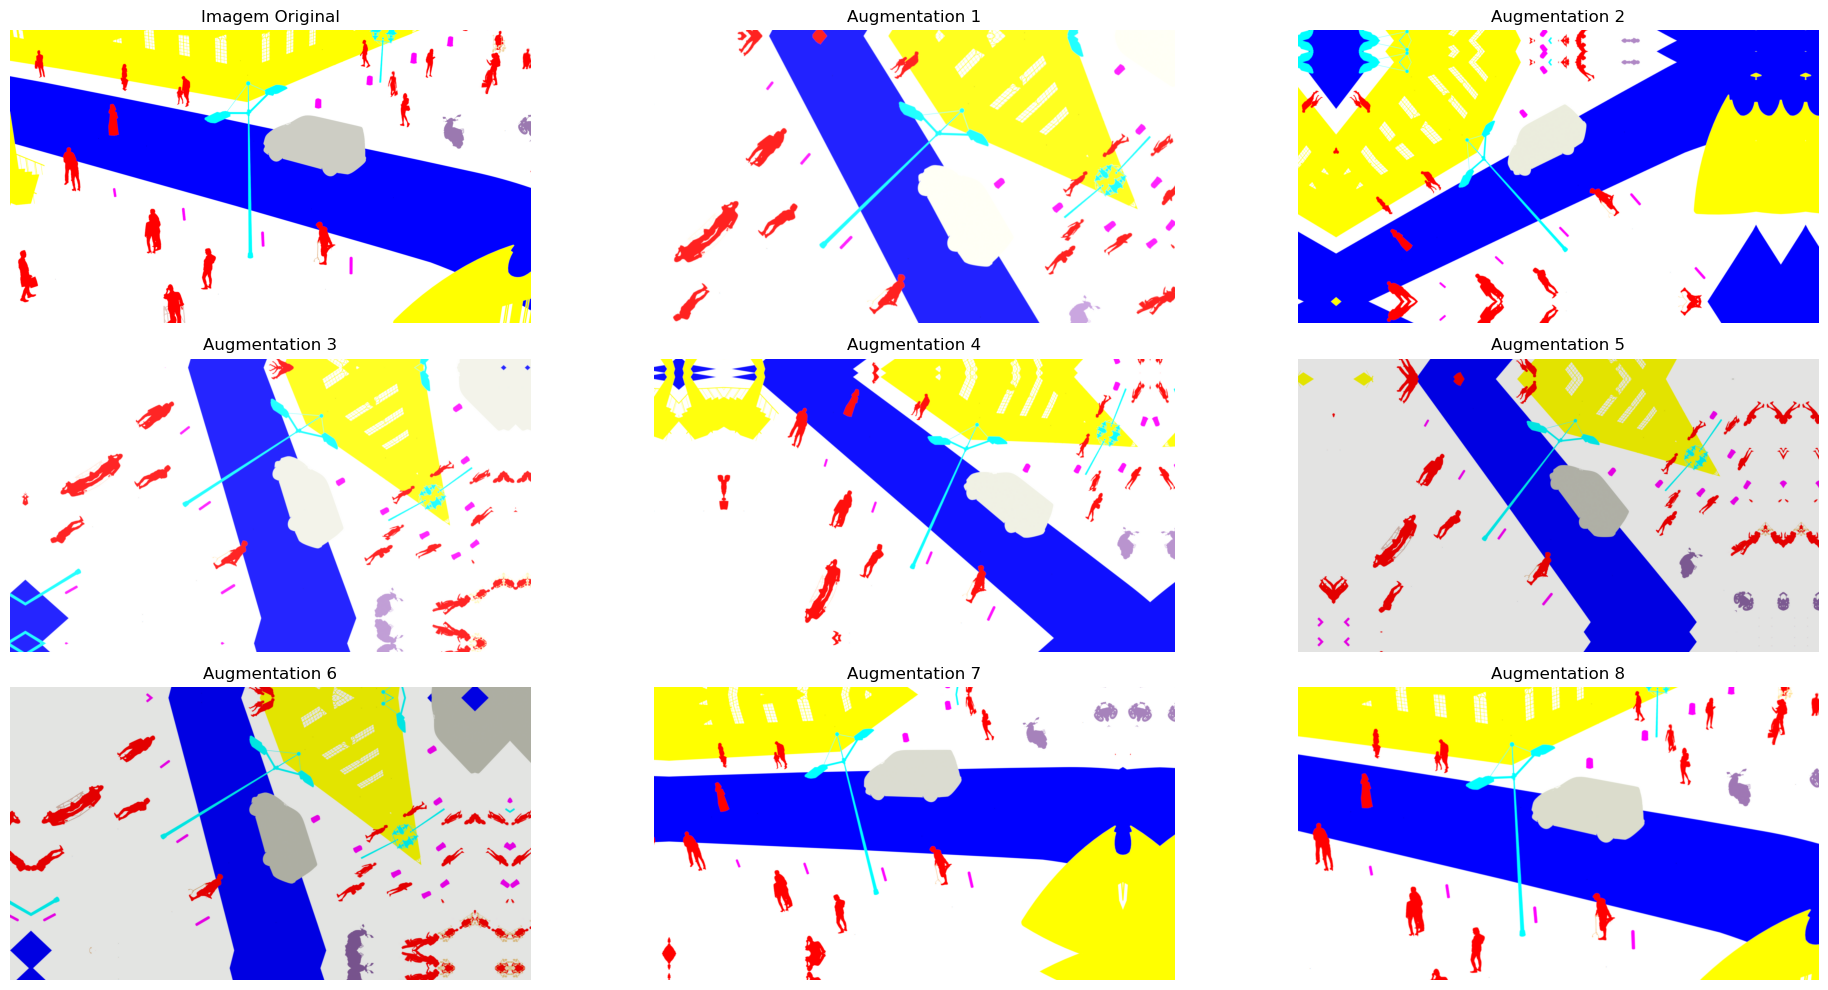

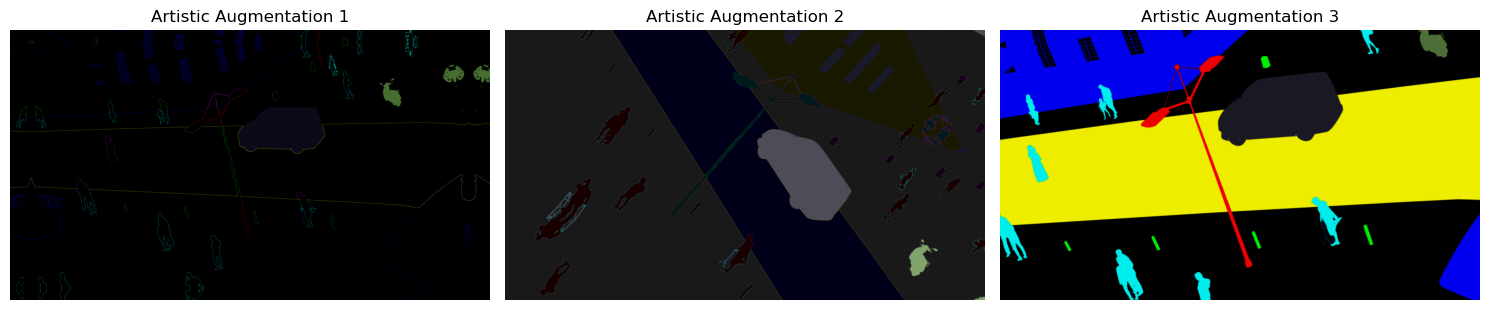

2025-01-15 10:24:56.625437: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


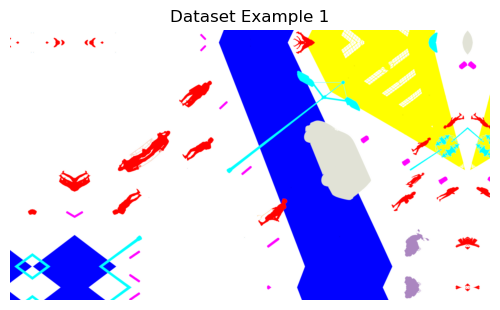

In [41]:
# https://keras.io/api/layers/preprocessing_layers/image_augmentation/pipeline/

"""
É partir daqui onde preciso trabalhar no projeto.
"""

import tensorflow as tf
import matplotlib.pyplot as plt

# Carregar uma imagem
image = tf.keras.utils.load_img(mask_path)
image_tensor = tf.keras.utils.img_to_array(image)
image_batch = tf.expand_dims(image_tensor, 0)

# Criar uma pipeline de augmentation
augmentation_pipeline = tf.keras.layers.Pipeline([
    # Ajustes de aparência
    tf.keras.layers.RandomBrightness(factor=0.2),
    tf.keras.layers.RandomContrast(factor=0.2),
    
    # Transformações geométricas
    tf.keras.layers.RandomRotation(factor=0.2),
    tf.keras.layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    ),
    tf.keras.layers.RandomZoom(
        height_factor=(-0.2, 0.2)
    )
])

# Gerar múltiplas versões aumentadas
num_examples = 8
plt.figure(figsize=(20, 10))

# Imagem original
plt.subplot(3, 3, 1)
plt.imshow(image_tensor.astype('uint8'))
plt.title('Imagem Original')
plt.axis('off')

# Versões aumentadas
for i in range(num_examples):
    # Aplicar a pipeline de augmentation
    augmented = augmentation_pipeline(image_batch, training=True)
    
    plt.subplot(3, 3, i + 2)
    plt.imshow(augmented[0].numpy().astype('uint8'))
    plt.title(f'Augmentation {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Criar uma segunda pipeline mais específica
artistic_pipeline = tf.keras.layers.Pipeline([
    # Primeiro ajustes de aparência
    tf.keras.layers.RandomBrightness(factor=0.3),
    tf.keras.layers.RandomContrast(factor=0.3),
    tf.keras.layers.Solarization(threshold_factor=0.3),
    
    # Depois transformações geométricas
    tf.keras.layers.RandomRotation(factor=0.2),
    tf.keras.layers.RandomZoom(height_factor=(-0.3, 0.1))
])

# Mostrar exemplos da pipeline artística
plt.figure(figsize=(15, 5))
for i in range(3):
    augmented = artistic_pipeline(image_batch, training=True)
    plt.subplot(1, 3, i + 1)
    plt.imshow(augmented[0].numpy().astype('uint8'))
    plt.title(f'Artistic Augmentation {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Demonstrar uso com tf.data.Dataset
# Criar um pequeno dataset de exemplo
dataset = tf.data.Dataset.from_tensor_slices([image_tensor])

# Aplicar a pipeline usando map
augmented_dataset = dataset.map(
    lambda x: augmentation_pipeline(x, training=True),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Mostrar alguns exemplos do dataset
plt.figure(figsize=(15, 5))
for i, augmented_image in enumerate(augmented_dataset.take(3)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(augmented_image.numpy().astype('uint8'))
    plt.title(f'Dataset Example {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Encontradas 5036 imagens

Primeiros 5 caminhos de imagem:
/media/renato/Data/PIBIC/FinalImagePPM_Mask/000.png
/media/renato/Data/PIBIC/FinalImagePPM_Mask/001.png
/media/renato/Data/PIBIC/FinalImagePPM_Mask/002.png
/media/renato/Data/PIBIC/FinalImagePPM_Mask/003.png
/media/renato/Data/PIBIC/FinalImagePPM_Mask/004.png

Verificando primeiro item do dataset:
Caminho: /media/renato/Data/PIBIC/FinalImagePPM_Mask/000.png
Arquivo existe: True


2025-01-21 10:58:09.669116: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


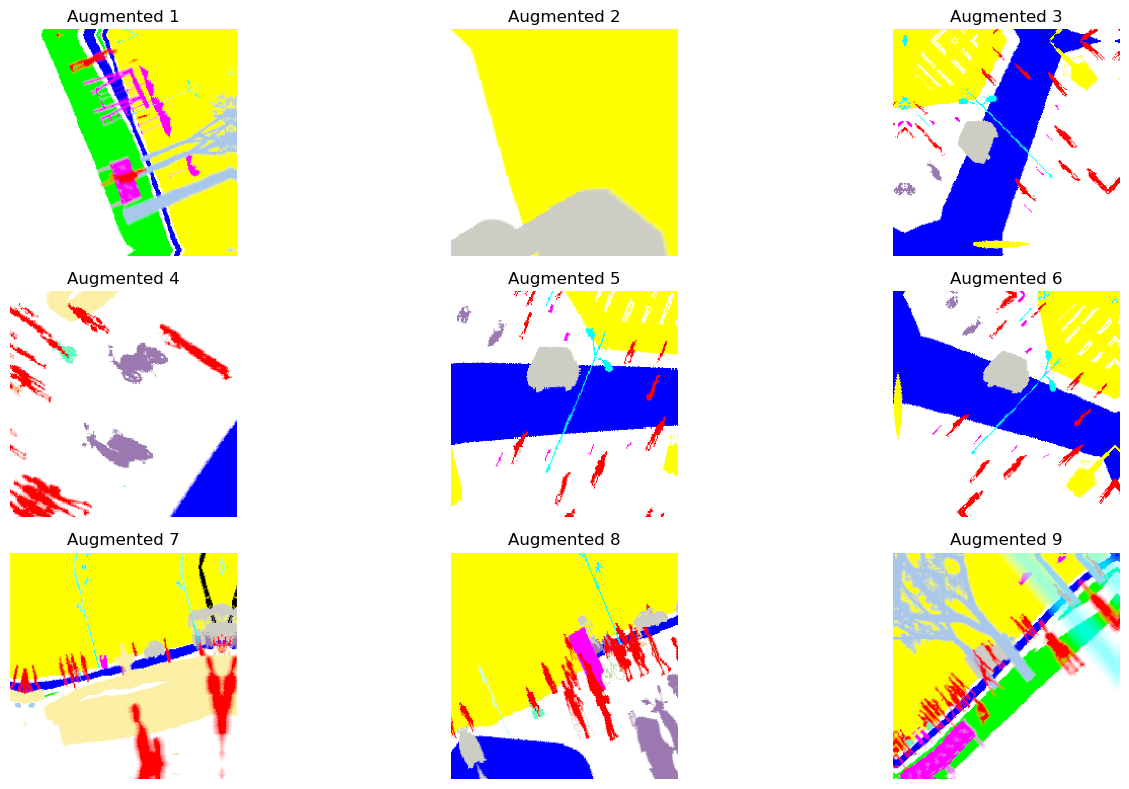


Número total de imagens: 5036
Número de batches: 158


In [ ]:
import tensorflow as tf
import pathlib
import matplotlib.pyplot as plt
import os

"""
Teste de uso das imagens do projeto real
Sucesso!
"""

# 1. Configurar o caminho e criar lista de imagens
data_dir = '/media/renato/Data/PIBIC/FinalImagePPM_Mask'
data_dir = pathlib.Path(data_dir)

# Verificar se o diretório existe
if not os.path.exists(data_dir):
    raise ValueError(f"Diretório não encontrado: {data_dir}")

# Função para extrair o número do nome do arquivo
def get_file_number(filepath):
    return int(os.path.basename(filepath).replace('.png', ''))

# Verificar se os arquivos existem e converter PosixPath para strings 
image_files = []
for path in data_dir.glob('*.png'):
    if os.path.exists(path):
        image_files.append(str(path))

# Ordenar a lista usando o número do arquivo como chave
image_files = sorted(image_files, key=get_file_number)

image_count = len(image_files)
print(f"Encontradas {image_count} imagens")

# Verificar se temos imagens
if image_count == 0:
    raise ValueError(f"Nenhuma imagem PNG encontrada em: {data_dir}")

# Mostrar alguns caminhos de exemplo
print("\nPrimeiros 5 caminhos de imagem:")
for path in image_files[:5]:
    print(path)

# 2. Criar função para carregar e processar imagens
def load_and_preprocess_image(path):
    try:
        # Converter path para string
        img_path = tf.convert_to_tensor(path, dtype=tf.string)
        
        # Ler arquivo
        img = tf.io.read_file(img_path)
        
        # Decodificar imagem mantendo os 3 canais de cor
        img = tf.image.decode_png(img, channels=3)
        
        # Converter para float32 e normalizar
        img = tf.cast(img, tf.float32) / 255.0
        
        # Redimensionar para tamanho padrão
        # Usar interpolação nearest para preservar as cores exatas
        img = tf.image.resize(img, [224, 224], method='nearest')
        
        return img
    except Exception as e:
        print(f"Erro ao processar imagem {path}: {str(e)}")
        raise

# 3. Criar pipeline de data augmentation
augmentation_pipeline = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2, interpolation='nearest'),
    tf.keras.layers.RandomZoom(0.2, interpolation='nearest'),
    # Não usar RandomBrightness e RandomContrast para não afetar as cores das máscaras
])

# 4. Criar e configurar o dataset
# Criar dataset dos caminhos das imagens
path_dataset = tf.data.Dataset.from_tensor_slices(image_files)

# Verificar o primeiro item do dataset
print("\nVerificando primeiro item do dataset:")
for path in path_dataset.take(1):
    print(f"Caminho: {path.numpy().decode()}")
    print(f"Arquivo existe: {os.path.exists(path.numpy().decode())}")

# Carregar e preprocessar imagens
image_dataset = path_dataset.map(
    load_and_preprocess_image, 
    num_parallel_calls=tf.data.AUTOTUNE
)

# Configurar o dataset para treinamento
BATCH_SIZE = 32
BUFFER_SIZE = 1000

train_dataset = (image_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .map(
        lambda x: augmentation_pipeline(x, training=True),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .prefetch(tf.data.AUTOTUNE)
)

# 5. Tentar visualizar algumas imagens
try:
    plt.figure(figsize=(15, 8))
    for i, images in enumerate(train_dataset.take(1)):
        for j in range(min(9, BATCH_SIZE)):
            plt.subplot(3, 3, j+1)
            plt.imshow(images[j])
            plt.title(f'Augmented {j+1}')
            plt.axis('off')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Erro ao visualizar imagens: {str(e)}")

# 6. Informações úteis sobre o dataset
print(f"\nNúmero total de imagens: {image_count}")
print(f"Número de batches: {tf.data.experimental.cardinality(train_dataset)}")